# Machine Learning Based Network Intrusion Detection System

## 1. Problem Definition & Objective

In [5]:
import pandas as pd

df = pd.read_csv("datasets/UNSW_NB15_training-set.csv")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 175341
Columns: 45


## 2. Dataset Loaded

The UNSW-NB15 dataset was used for this project because it represents realistic network traffic containing both normal activity and different types of cyber attacks. The dataset was developed to support research in network intrusion detection and contains network traffic features that can be used to distinguish normal traffic from malicious activity.

The training dataset used in this project is `UNSW_NB15_training-set.csv`. The target label is used to classify network traffic as either normal or malicious.

In [6]:
df.head()

,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.121478,tcp,-,FIN,6,4,258,172,74.087490,...,1,1,0,0,0,1,1,0,Normal,0
1,2,0.649902,tcp,-,FIN,14,38,734,42014,78.473372,...,1,2,0,0,0,1,6,0,Normal,0
2,3,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,...,1,3,0,0,0,2,6,0,Normal,0
3,4,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,...,1,3,1,1,0,2,1,0,Normal,0
4,5,0.449454,tcp,-,FIN,10,6,534,268,33.373826,...,1,40,0,0,0,2,39,0,Normal,0


In [7]:
df.shape

(175341, 45)

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 175341 entries, 0 to 175340
Data columns (total 45 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 175341 non-null  int64  
 1   dur                175341 non-null  float64
 2   proto              175341 non-null  str    
 3   service            175341 non-null  str    
 4   state              175341 non-null  str    
 5   spkts              175341 non-null  int64  
 6   dpkts              175341 non-null  int64  
 7   sbytes             175341 non-null  int64  
 8   dbytes             175341 non-null  int64  
 9   rate               175341 non-null  float64
 10  sttl               175341 non-null  int64  
 11  dttl               175341 non-null  int64  
 12  sload              175341 non-null  float64
 13  dload              175341 non-null  float64
 14  sloss              175341 non-null  int64  
 15  dloss              175341 non-null  int64  
 16  sinpkt       

In [9]:
df.isnull().sum()

id                   0
dur                  0
proto                0
service              0
state                0
spkts                0
dpkts                0
sbytes               0
dbytes               0
rate                 0
sttl                 0
dttl                 0
sload                0
dload                0
sloss                0
dloss                0
sinpkt               0
dinpkt               0
sjit                 0
djit                 0
swin                 0
stcpb                0
dtcpb                0
dwin                 0
tcprtt               0
synack               0
ackdat               0
smean                0
dmean                0
trans_depth          0
response_body_len    0
ct_srv_src           0
ct_state_ttl         0
ct_dst_ltm           0
ct_src_dport_ltm     0
ct_dst_sport_ltm     0
ct_dst_src_ltm       0
is_ftp_login         0
ct_ftp_cmd           0
ct_flw_http_mthd     0
ct_src_ltm           0
ct_srv_dst           0
is_sm_ips_ports      0
attack_cat 

## 3. Data Preprocessing

In [10]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


In [11]:
df["label"].value_counts()

label
1    119341
0     56000
Name: count, dtype: int64

Matplotlib is building the font cache; this may take a moment.


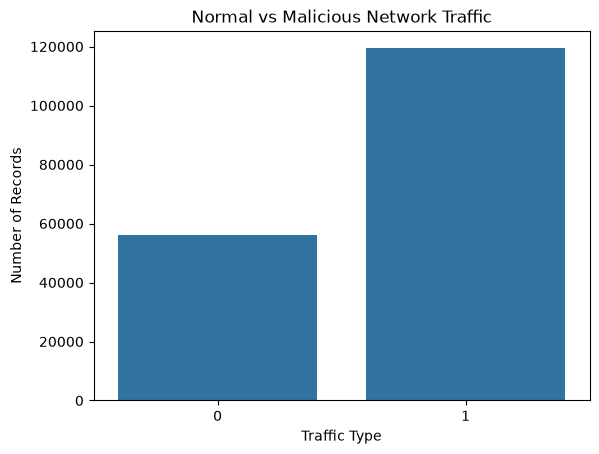

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x="label", data=df)

plt.title("Normal vs Malicious Network Traffic")
plt.xlabel("Traffic Type")
plt.ylabel("Number of Records")

plt.show()

In [13]:
print("0 = Normal traffic")
print("1 = Malicious traffic")

0 = Normal traffic
1 = Malicious traffic


In [14]:
df.select_dtypes(include="object").columns

C:\Users\misha\AppData\Local\Temp\ipykernel_16432\1196084386.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include="object").columns


Index(['proto', 'service', 'state', 'attack_cat'], dtype='str')

In [15]:
df.dtypes

id                     int64
dur                  float64
proto                    str
service                  str
state                    str
spkts                  int64
dpkts                  int64
sbytes                 int64
dbytes                 int64
rate                 float64
sttl                   int64
dttl                   int64
sload                float64
dload                float64
sloss                  int64
dloss                  int64
sinpkt               float64
dinpkt               float64
sjit                 float64
djit                 float64
swin                   int64
stcpb                  int64
dtcpb                  int64
dwin                   int64
tcprtt               float64
synack               float64
ackdat               float64
smean                  int64
dmean                  int64
trans_depth            int64
response_body_len      int64
ct_srv_src             int64
ct_state_ttl           int64
ct_dst_ltm             int64
ct_src_dport_l

In [16]:
df = df.drop(columns=["id", "attack_cat"])

In [17]:
print(df.columns)

Index(['dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes',
       'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss',
       'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin',
       'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth',
       'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm',
       'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm',
       'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm',
       'ct_srv_dst', 'is_sm_ips_ports', 'label'],
      dtype='str')


In [18]:
X = df.drop(columns=["label"])
y = df["label"]

In [19]:
X.select_dtypes(include="object").columns

C:\Users\misha\AppData\Local\Temp\ipykernel_16432\2213039483.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  X.select_dtypes(include="object").columns


Index(['proto', 'service', 'state'], dtype='str')

In [20]:
X = pd.get_dummies(X, drop_first=True)


In [21]:
print("X shape after encoding:", X.shape)

X shape after encoding: (175341, 191)


In [22]:
print("Missing values:", X.isnull().sum().sum())

Missing values: 0


In [24]:
import numpy as np

In [25]:
print("Infinite values:", np.isinf(X.select_dtypes(include=np.number)).sum().sum())

Infinite values: 0


In [26]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## 4. Train-Test Split

In [27]:
print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

print("Training labels:", y_train.shape)
print("Testing labels:", y_test.shape)

Training features: (140272, 191)
Testing features: (35069, 191)
Training labels: (140272,)
Testing labels: (35069,)


## 5. Random Forest Model

In [28]:
from sklearn.ensemble import RandomForestClassifier

In [29]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

In [30]:
model.fit(X_train, y_train)

print("Model training completed!")

Model training completed!


In [31]:
y_pred = model.predict(X_test)

print("Predictions completed!")

Predictions completed!


## 6. Model Prediction & Evaluation

In [32]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.9597650346459836
Precision: 0.9636633908662978
Recall: 0.9777535715781976
F1 Score: 0.970657350219394


##  Exploratory Data Analysis

## 7. Confusion Matrix

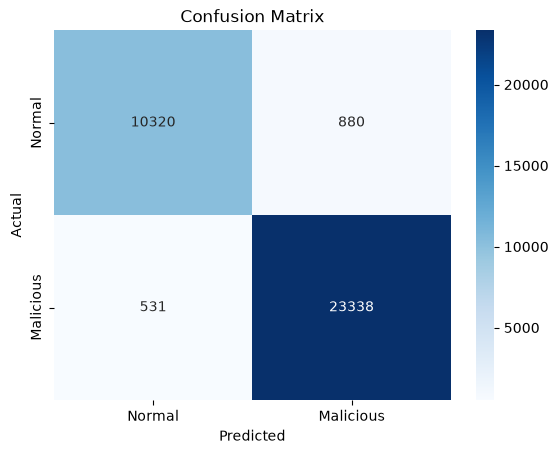

In [34]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Malicious"],
    yticklabels=["Normal", "Malicious"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("results/confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

In [35]:
feature_importance = pd.Series(
    model.feature_importances_,
    index=X.columns
)

feature_importance = feature_importance.sort_values(ascending=False)

print(feature_importance.head(10))

sttl            0.097360
ct_state_ttl    0.073427
rate            0.070849
dload           0.062089
sload           0.043716
dmean           0.042638
dttl            0.039085
ackdat          0.036202
sbytes          0.035987
ct_srv_dst      0.033465
dtype: float64


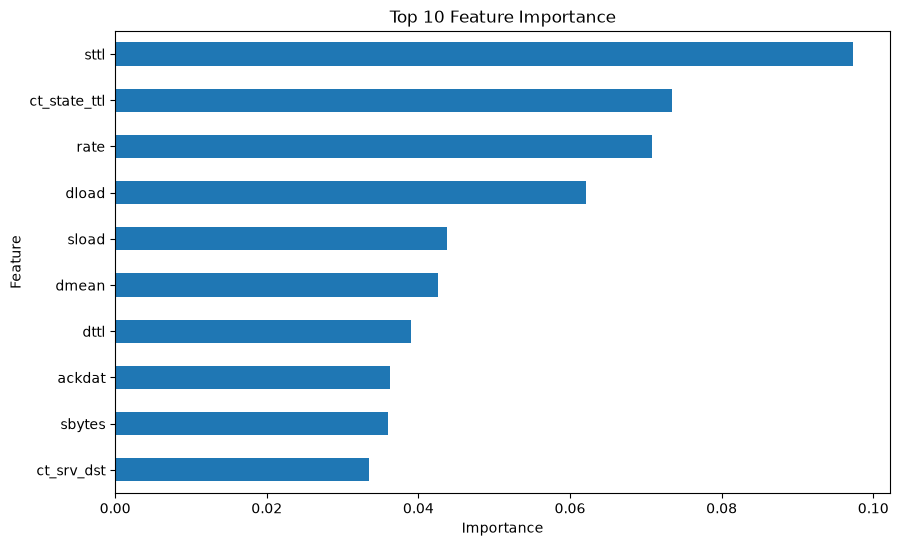

In [36]:
plt.figure(figsize=(10, 6))

feature_importance.head(10).sort_values().plot(kind="barh")

plt.title("Top 10 Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.savefig("results/feature_importance.png", dpi=300, bbox_inches="tight")

plt.show()

In [38]:
results = {
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1
}

print("Final Model Performance")
print("-----------------------")

for metric, value in results.items():
    print(f"{metric}: {value:.4f}")

Final Model Performance
-----------------------
Accuracy: 0.9598
Precision: 0.9637
Recall: 0.9778
F1 Score: 0.9707


In [39]:
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[10320   880]
 [  531 23338]]


## 9. Security Error Analysis

In [40]:
tn, fp, fn, tp = cm.ravel()

false_positive_rate = fp / (fp + tn)
false_negative_rate = fn / (fn + tp)

print("False Positive Rate:", false_positive_rate)
print("False Negative Rate:", false_negative_rate)

False Positive Rate: 0.07857142857142857
False Negative Rate: 0.022246428421802338


In [41]:
import pandas as pd

final_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "False Positive Rate",
        "False Negative Rate"
    ],
    "Value": [
        accuracy,
        precision,
        recall,
        f1,
        false_positive_rate,
        false_negative_rate
    ]
})

final_results.to_csv("results/final_model_results.csv", index=False)

print(final_results)

                Metric     Value
0             Accuracy  0.959765
1            Precision  0.963663
2               Recall  0.977754
3             F1 Score  0.970657
4  False Positive Rate  0.078571
5  False Negative Rate  0.022246


## Final Model Evaluation

The Random Forest classifier achieved an accuracy of 95.98% on the test dataset.

The model achieved a precision of 96.37%, recall of 97.78%, and F1 score of 97.07%. The high recall indicates that the model was able to correctly identify most malicious network traffic.

The confusion matrix showed 23,338 true positive malicious instances and 531 false negatives. The false negative rate was 2.22%, meaning that a relatively small proportion of malicious traffic was incorrectly classified as normal.

The false positive rate was 7.86%, indicating that some legitimate traffic was incorrectly classified as malicious. In a real NIDS, these false positives could generate additional alerts for security analysts.

Feature importance analysis showed that `sttl`, `ct_state_ttl`, and `rate` were among the most influential features used by the Random Forest classifier.

Overall, the results demonstrate that the developed machine learning model has potential as a proof-of-concept tool for automatically distinguishing normal and malicious network traffic.